
# **Instituto Tecnológico y de Estudios Superiores de Monterrey**
## **Maestría en Inteligencia Artificial Aplicada**
### **Proyecto integrador (TC5035.10)**
### **Algoritmos de regresión de Machine Learning para la estimación del carbono en bosques mezclados de Durango**
####    **Avance 1. Análisis Exploratorio de Datos (EDA)**
####    **Dra. Maria Valentina Narváez Teran**
#####    Gerónimo Quiñónez Barraza – A01795904
#####    Alfredo Rigoberto Álvarez Suárez – A01796142
#####    Humberto Alonso Torres Hernández – A01793682
Durango, Dgo.12 de mayo de 2025


## Análisis exploratorio de datos (EDA)
El Análisis Exploratorio de Datos (EDA, Exploratory Data Analysis) es una etapa esencial dentro de la ciencia de datos y el aprendizaje automático, cuyo propósito es comprender la estructura, calidad y comportamiento de un conjunto de datos antes de aplicar modelos estadísticos o algoritmos predictivos. Mediante el uso de estadísticas descriptivas y técnicas de visualización, el EDA permite identificar patrones, tendencias, relaciones entre variables, valores faltantes, datos atípicos y posibles inconsistencias, facilitando una mejor interpretación de la información y apoyando la toma de decisiones basada en evidencia. Asimismo, este proceso contribuye a mejorar la calidad de los datos y optimizar las etapas posteriores de preparación, transformación y modelado analítico

## Objetivo
Realizar un análisis exploratorio de datos (EDA) para comprender la estructura, calidad y comportamiento del conjunto de datos.
La variable objetivo es el dioxido de carbo equivalente por hectarea (CO₂eA).

# Importación de librerías
Este bloque de código realiza la importación y configuración inicial de las librerías necesarias para el análisis exploratorio de datos. Se incluyen herramientas para manipulación de datos (pandas, numpy), visualización gráfica (matplotlib, seaborn) y normalización de variables (MinMaxScaler), además de configuraciones visuales y de despliegue para facilitar la interpretación de los resultados.

In [25]:
#@title Importación de librerías
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

sns.set_style("whitegrid")

pd.set_option('display.max_columns', None)


# Conexión con Google Drive
Este bloque de código permite establecer la conexión entre Google Colab y Google Drive, facilitando el acceso a archivos, datasets y carpetas almacenadas en la nube para su análisis y procesamiento dentro del entorno de trabajo.

In [26]:
#@title Conexión con Google Drive
from google.colab import drive

drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# Carga del dataset
Este bloque de código realiza la carga del conjunto de datos desde un archivo de Excel almacenado en Google Drive utilizando la librería pandas. Posteriormente, se visualizan las primeras filas del dataset con el objetivo de verificar que la información se haya importado correctamente y conocer la estructura inicial de los datos.

In [27]:
#@title Carga del dataset
#file_path = '/content/drive/Shareddrives/MNA_Proyecto_Integrador/data/dataset.xlsx'
file_path = '/content/sample_data/dataset.xlsx'
df = pd.read_excel(file_path)

df.head()

,plot,utmx,utmy,EVI,GNDVI,MSI,NBR,NDBI,NDMI,NDVI,NDWI,SAVI,aspect,curvature,elevation,roughness,slope,bulk_density,depth_m,pH,pH_norm,SOC_frac,SOC_index,SOC,SOC_stock,co,te,pm,om,S,Shannon,Simpson,density,ba,biomass,carbono,CO2eA,CO2eS
0,1,388941,2790284,0.237276,0.560800,1.066497,0.170449,0.032178,-0.032178,0.511641,-0.560800,0.253230,67.647461,22,2667,6.878597,12.014798,1.3,0.3,57,4.071429,0.005,0.05,5,19.5,1,2,1,1,6,1.502652,0.250740,550,42.286623,250.494396,125.247198,459.239768,71.565
1,2,388991,2790316,0.203653,0.527561,1.182096,0.098617,0.083450,-0.083450,0.465754,-0.527561,0.217924,58.906067,1,2662,4.945361,3.587151,1.3,0.3,55,3.928571,0.005,0.05,5,19.5,1,1,1,1,8,1.932229,0.155556,470,24.070035,138.437386,69.218693,253.801897,71.565
2,3,388917,2790436,0.257262,0.646510,0.854502,0.315705,-0.078456,0.078456,0.656101,-0.646510,0.274659,41.487507,6,2655,12.071330,17.959806,1.3,0.3,57,4.071429,0.005,0.05,5,19.5,2,2,1,3,7,1.532161,0.265306,360,33.044811,221.878412,110.939206,406.777125,71.565
3,4,389150,2790330,0.249365,0.623246,0.896234,0.270783,-0.054722,0.054722,0.587128,-0.623246,0.266462,318.512756,-6,2673,5.990678,6.166752,1.3,0.3,55,3.928571,0.005,0.05,5,19.5,2,1,1,1,6,1.407245,0.280800,560,29.107924,174.586684,87.293342,320.075616,71.565
4,5,389119,2790416,0.250293,0.596837,0.867249,0.258077,-0.071094,0.071094,0.551068,-0.596837,0.266166,10.438908,9,2658,6.995667,5.640312,1.3,0.3,55,3.928571,0.005,0.05,5,19.5,2,2,1,1,5,1.188849,0.357002,410,33.743658,233.899568,116.949784,428.815913,71.565


Las variables son plot	Identificador de parcela
*utmx* = Coordenada UTM X; *utmy* = Coordenada UTM Y; *EVI* = Índice de vegetación mejorado; *GNDVI* = Índice de vegetación verde; *MSI* = Índice de estrés hídrico;
*NBR* =	Índice de severidad de disturbio; *NDBI* =	Índice de áreas construidas/suelo; *NDMI* =	Índice de humedad; *NDVI* =	Índice de vegetación; *NDWI* =	Índice de agua; *SAVI* = Índice de vegetación ajustado al suelo; *aspect* = Exposición del terreno; *curvature* =	Curvatura del terreno; `elevation` =	Altitud; roughness = *Rugosidad* del terreno; *slope* =	Pendiente; *bulk_density* =	Densidad aparente del suelo; *depth_m* =	Profundidad del suelo; *pH* =	Acidez del suelo; *pH_norm* =	pH normalizado; *SOC_frac* =	Fracción de carbono del suelo; *SOC_index* = Índice relativo de carbono; *SOC* = Carbono orgánico del suelo; *SOC_stock* =	Stock de carbono del suelo; *co* = Compactación del suelo; *te* =	Textura del suelo; *pm* =	Material predominante del suelo; *om* =	Materia orgánica del suelo; *S* =	Equidad de especies; *Shannon* =	Índice de diversidad de Shannon; *Simpson* = Índice de diversidad de Simpson; *density* =	Densidad de arbolado; *ba* = Área basal; *biomass* =	Biomasa aérea; *carbono* =	Carbono en biomasa; *CO₂eA* =	CO₂e dioxido de carbono aereo; *CO₂eS* =	CO₂e suelo.


In [28]:
#@title Definición de variables
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

categorical_cols = ['co','te','pm']

# 1. ¿Hay valores faltantes en el conjunto de datos? ¿Se pueden identificar patrones de ausencia?


Estos bloques de código permite identificar y cuantificar los valores faltantes presentes en el conjunto de datos, mostrando únicamente aquellas variables que contienen datos ausentes. Posteriormente, se genera un mapa de calor (heatmap) que facilita la visualización de la distribución y posibles patrones de ausencia dentro del dataset, apoyando la evaluación de la calidad de los datos antes del análisis o modelado.

In [ ]:
#@title Análisis de valores faltantes
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)

Series([], dtype: int64)


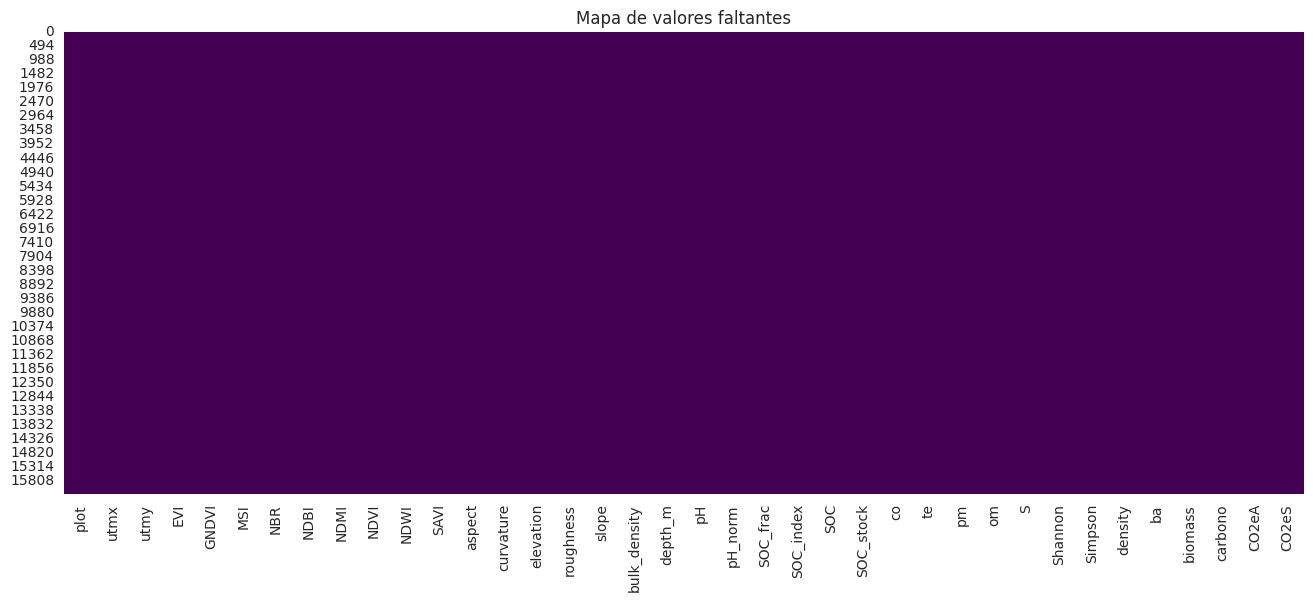

In [ ]:
#@title Mapa de valores faltantes
plt.figure(figsize=(16,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title('Mapa de valores faltantes')

plt.show()

In [ ]:
#@title Tabla de valores faltantes
missing_table = pd.DataFrame({
    'Variable': df.columns,
    'Valores_Faltantes': df.isnull().sum(),
    'Porcentaje_Faltante (%)': (df.isnull().sum() / len(df)) * 100
})

missing_table = missing_table[missing_table['Valores_Faltantes'] > 0]

missing_table.sort_values(by='Valores_Faltantes',
                          ascending=False,
                          inplace=True)

missing_table

,Variable,Valores_Faltantes,Porcentaje_Faltante (%)


### Interpretación
El análisis de valores faltantes permite identificar posibles problemas de calidad de datos y detectar patrones de ausencia. **Para este caso no existen valores faltantes**.

# 2. ¿Cuáles son las estadísticas resumidas del conjunto de datos?


Este bloque de código realiza un análisis general de la estructura del conjunto de datos, mostrando el número de filas y columnas, los nombres de las variables, los tipos de datos y las principales estadísticas descriptivas de las variables numéricas, como media, desviación estándar, valores mínimos y máximos, facilitando una comprensión inicial del dataset.

In [ ]:
#@title Análisis de estadísticas resumidas
print(df.shape)

print(df.columns.tolist())

df.dtypes

df.describe().T

(16281, 38)
['plot', 'utmx', 'utmy', 'EVI', 'GNDVI', 'MSI', 'NBR', 'NDBI', 'NDMI', 'NDVI', 'NDWI', 'SAVI', 'aspect', 'curvature', 'elevation', 'roughness', 'slope', 'bulk_density', 'depth_m', 'pH', 'pH_norm', 'SOC_frac', 'SOC_index', 'SOC', 'SOC_stock', 'co', 'te', 'pm', 'om', 'S', 'Shannon', 'Simpson', 'density', 'ba', 'biomass', 'carbono', 'CO2eA', 'CO2eS']


,count,mean,std,min,25%,50%,75%,max
plot,16281.0,1.297359e+04,7.559801e+03,1.000000e+00,5.603000e+03,1.449200e+04,1.969100e+04,2.376500e+04
utmx,16281.0,3.952047e+05,6.678147e+03,3.784500e+05,3.913670e+05,3.956430e+05,3.992860e+05,4.103280e+05
utmy,16281.0,2.764612e+06,1.358782e+04,2.743780e+06,2.753700e+06,2.760498e+06,2.772686e+06,2.790505e+06
EVI,16281.0,2.789434e-01,4.823875e-02,8.766427e-02,2.454728e-01,2.789078e-01,3.124376e-01,4.909435e-01
GNDVI,16281.0,6.361630e-01,6.610384e-02,3.354864e-01,5.979959e-01,6.431495e-01,6.833593e-01,8.030079e-01
MSI,16281.0,8.311470e-01,1.810294e-01,4.261794e-01,6.942206e-01,8.068632e-01,9.405395e-01,1.603842e+00
NBR,16281.0,3.557079e-01,1.299554e-01,-1.267444e-01,2.696261e-01,3.666149e-01,4.539918e-01,6.745505e-01
NDBI,16281.0,-1.024565e-01,1.044159e-01,-4.023481e-01,-1.804838e-01,-1.068906e-01,-3.064124e-02,2.319042e-01
NDMI,16281.0,1.024565e-01,1.044159e-01,-2.319042e-01,3.064124e-02,1.068906e-01,1.804838e-01,4.023481e-01
NDVI,16281.0,6.329403e-01,9.300902e-02,2.500988e-01,5.774335e-01,6.438330e-01,7.016380e-01,8.432056e-01


### Interpretación
Las estadísticas descriptivas permiten identificar rangos de valores, dispersión y posibles anomalías.

# 3. ¿Hay valores atípicos en el conjunto de datos?


Estos bloques de código permiten analizar la presencia de valores atípicos (outliers) en las variables numéricas del conjunto de datos. Primero, se generan diagramas de caja (boxplots) para visualizar la distribución de cada variable y detectar posibles observaciones extremas. Posteriormente, se aplica el método del Rango Intercuartílico (IQR), el cual identifica de manera estadística los valores que se encuentran fuera de los límites considerados normales, facilitando la evaluación de la calidad y consistencia de los datos antes del modelado.

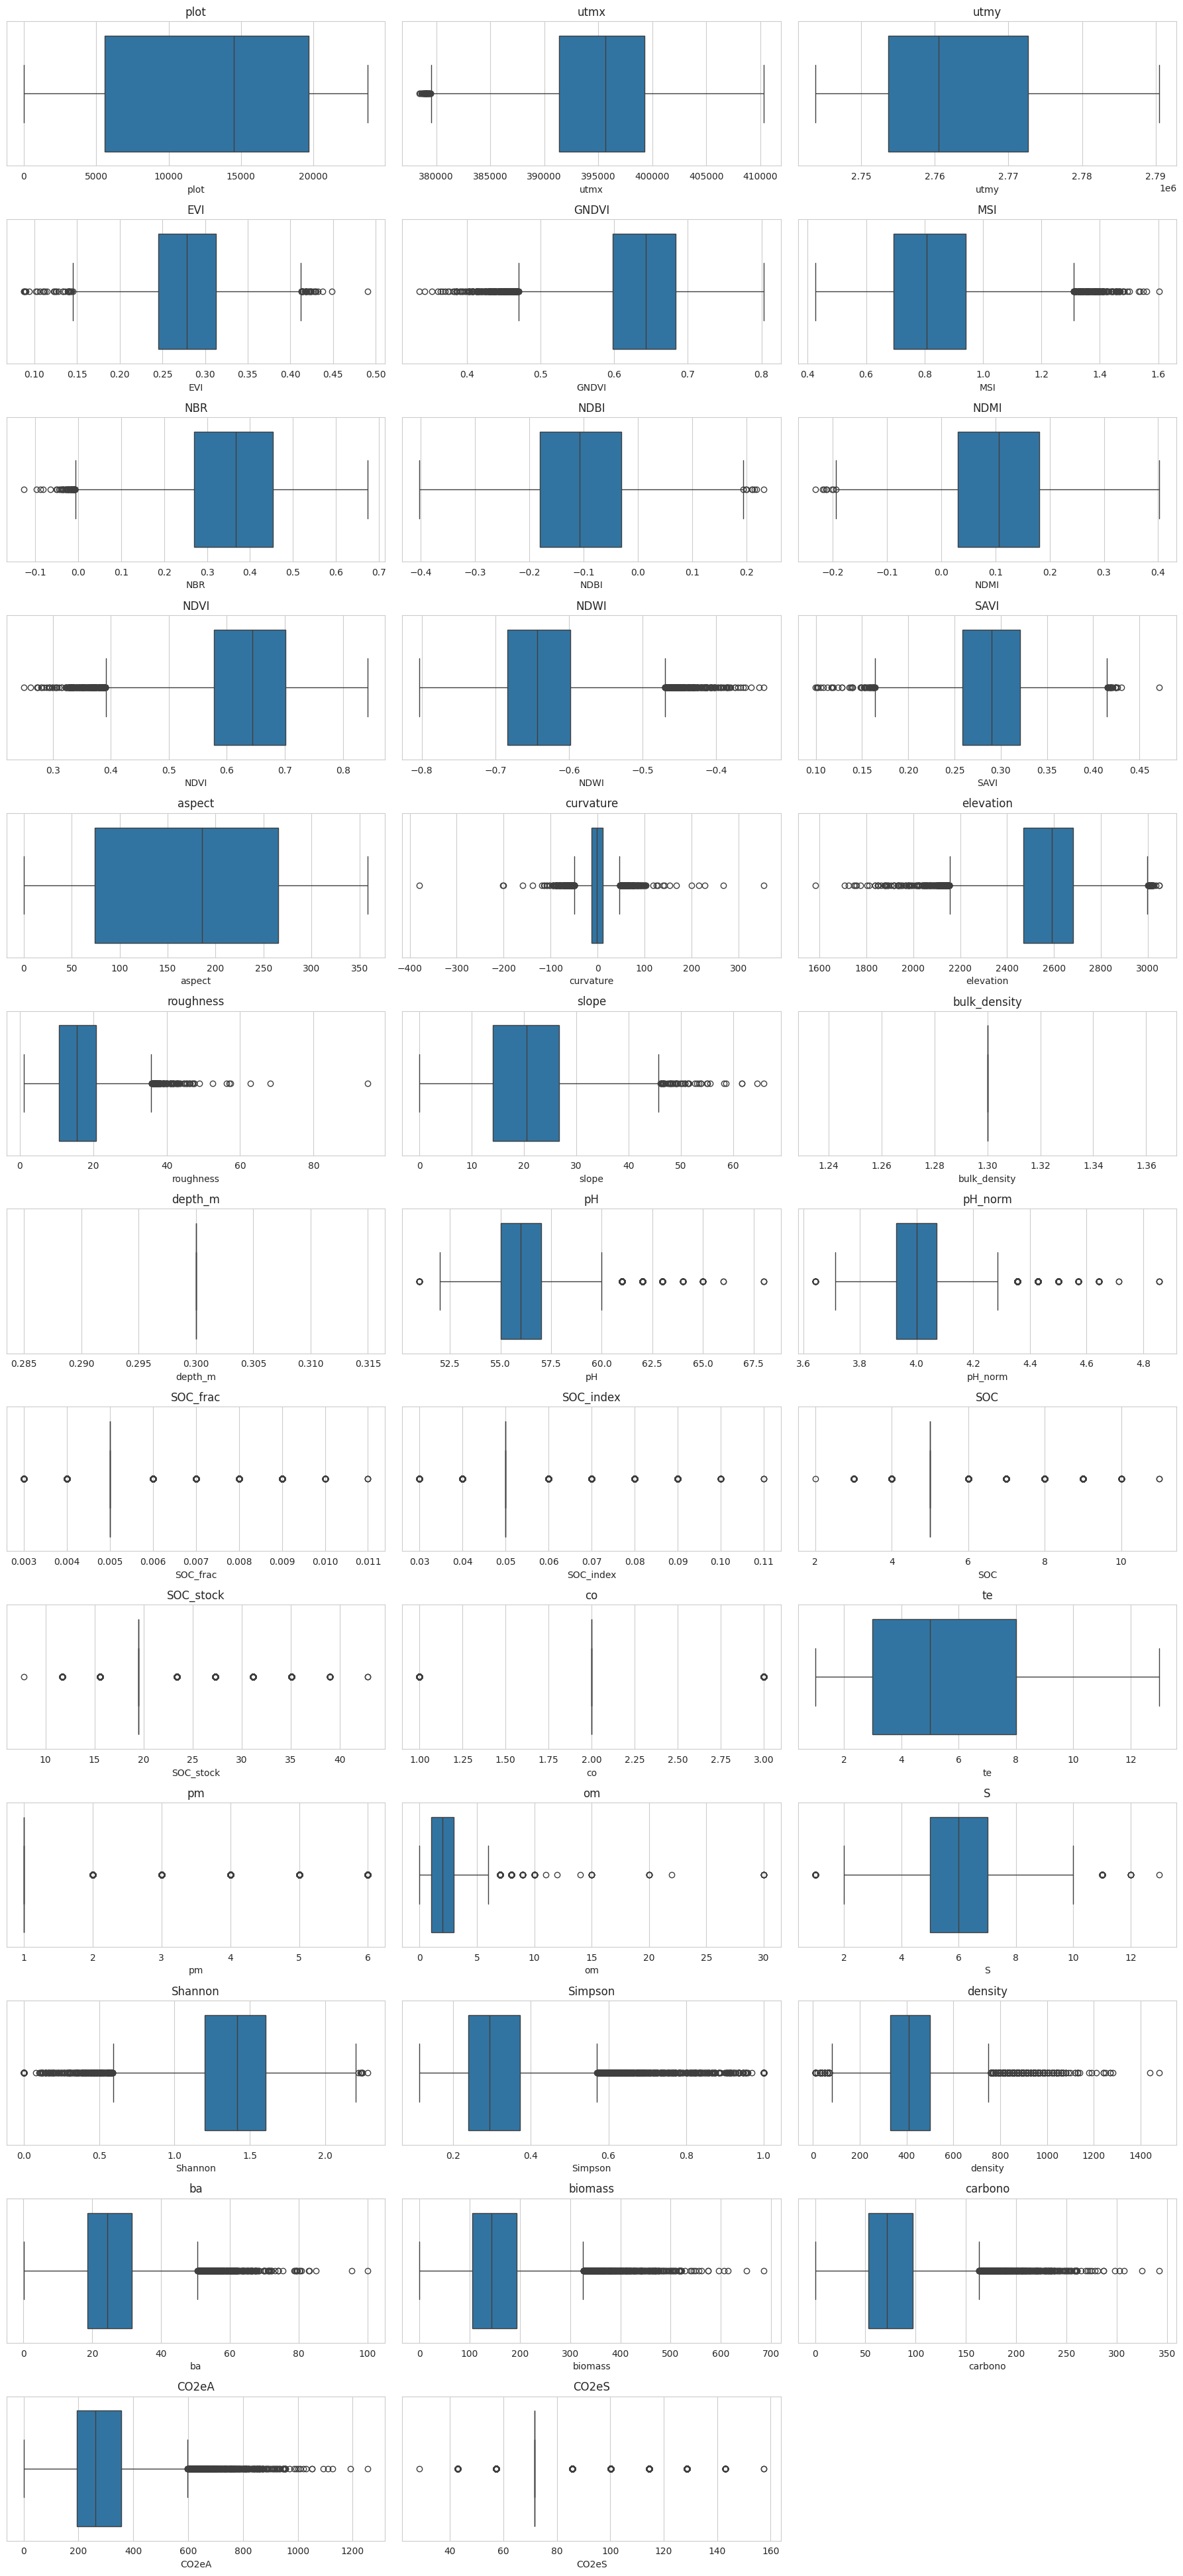

In [ ]:
#@title Boxplots de variables numéricas
n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(n_rows,
                         n_cols,
                         figsize=(18, n_rows * 3))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.boxplot(x=df[col], ax=axes[i])

    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
#@title Método IQR para identificar valores atípicos
Q1 = df[numerical_cols].quantile(0.25)

Q3 = df[numerical_cols].quantile(0.75)

IQR = Q3 - Q1

outliers = ((df[numerical_cols] < (Q1 - 1.5 * IQR)) |
            (df[numerical_cols] > (Q3 + 1.5 * IQR)))

print(outliers.sum())

plot               0
utmx              28
utmy               0
EVI               61
GNDVI            285
MSI              200
NBR               50
NDBI               8
NDMI               8
NDVI             226
NDWI             285
SAVI              69
aspect             0
curvature        526
elevation        231
roughness        112
slope             48
bulk_density       0
depth_m            0
pH               578
pH_norm          578
SOC_frac        6396
SOC_index       6396
SOC             6417
SOC_stock       6417
co              4687
te                 0
pm              3929
om               282
S                115
Shannon          308
Simpson          715
density          526
ba               408
biomass          486
carbono          486
CO2eA            486
CO2eS           6417
dtype: int64


### Interpretación
Los boxplots y el método IQR permiten identificar valores atípicos en variables forestales y ambientales. **Para este caso se identifican multiples variables con presencia de datos atipicos, se deberan evaluar posibles metodos de imputación, categorización  u otros para evitar sesgos en metodos estadisticos como la regresión lineal** .

# 4. ¿Cuál es la cardinalidad de las variables categóricas?


Estos bloques de código permiten analizar la cardinalidad y distribución de las variables categóricas del conjunto de datos. En primer lugar, se calcula el número de categorías únicas presentes en cada variable, lo que facilita identificar variables con alta o baja diversidad de clases. Posteriormente, se generan gráficos de conteo (countplots) para visualizar la frecuencia de cada categoría, permitiendo detectar posibles desbalances y comprender mejor la composición de los datos categóricos.

In [29]:
#@title Cardinalidad de variables categóricas
for col in categorical_cols:

    print(f'Variable: {col}')

    print("Cardinalidad:", df[col].nunique())

Variable: co
Cardinalidad: 3
Variable: te
Cardinalidad: 13
Variable: pm
Cardinalidad: 6


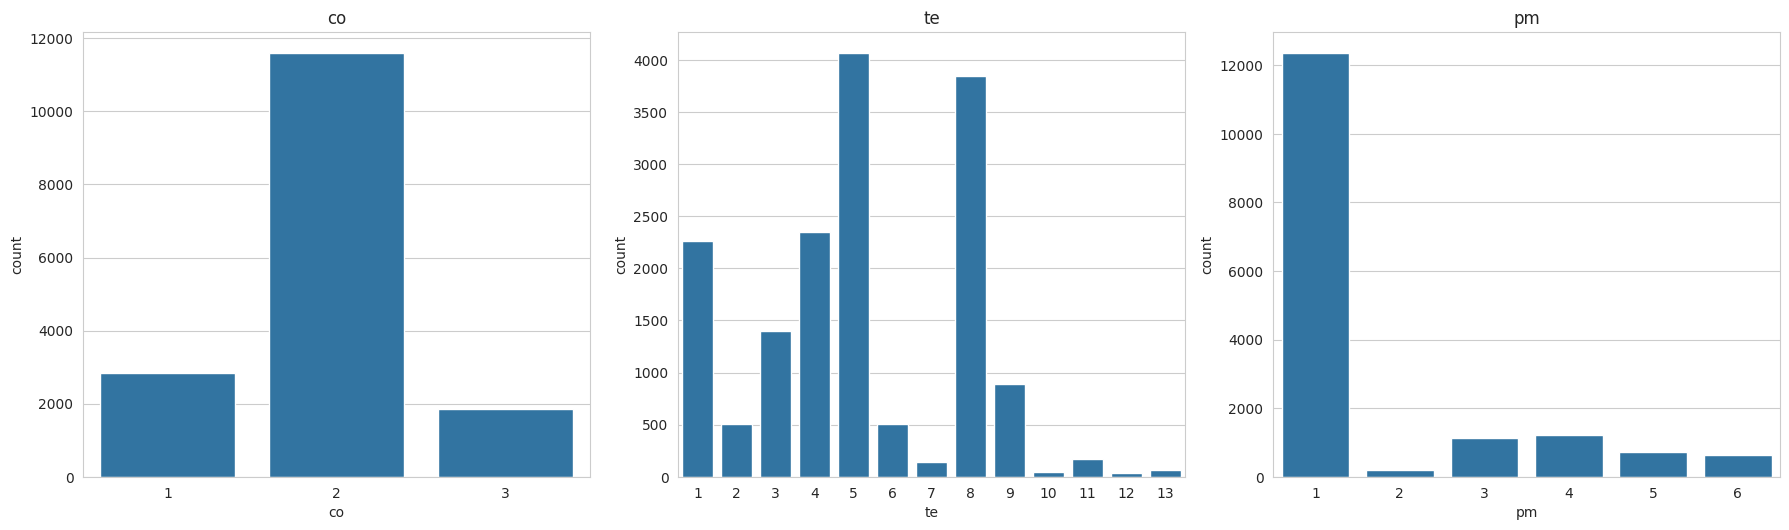

In [30]:
#@title Análisis de cardinalidad de variables categóricas
fig, axes = plt.subplots(2,
                         3,
                         figsize=(18,10))

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    sns.countplot(x=df[col], ax=axes[i])

    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Interpretación
La cardinalidad permite identificar el número de categorías únicas presentes en las variables categóricas.**Para este caso se identifica alta cardinalidad en una de las variables, se deberan evaluar posibles metodos de reduccion de clases** .

# 5. ¿Existen distribuciones sesgadas en el conjunto de datos? ¿Necesitamos aplicar alguna transformación no lineal?


Estos bloques de código permiten analizar la distribución de las variables numéricas del conjunto de datos. Primero, se generan histogramas acompañados de curvas de densidad para visualizar la forma de distribución de cada variable e identificar posibles comportamientos sesgados o no normales. Posteriormente, se calcula el coeficiente de asimetría (skewness), el cual cuantifica el nivel y dirección del sesgo en las distribuciones, facilitando la detección de variables que podrían requerir transformaciones antes del modelado.

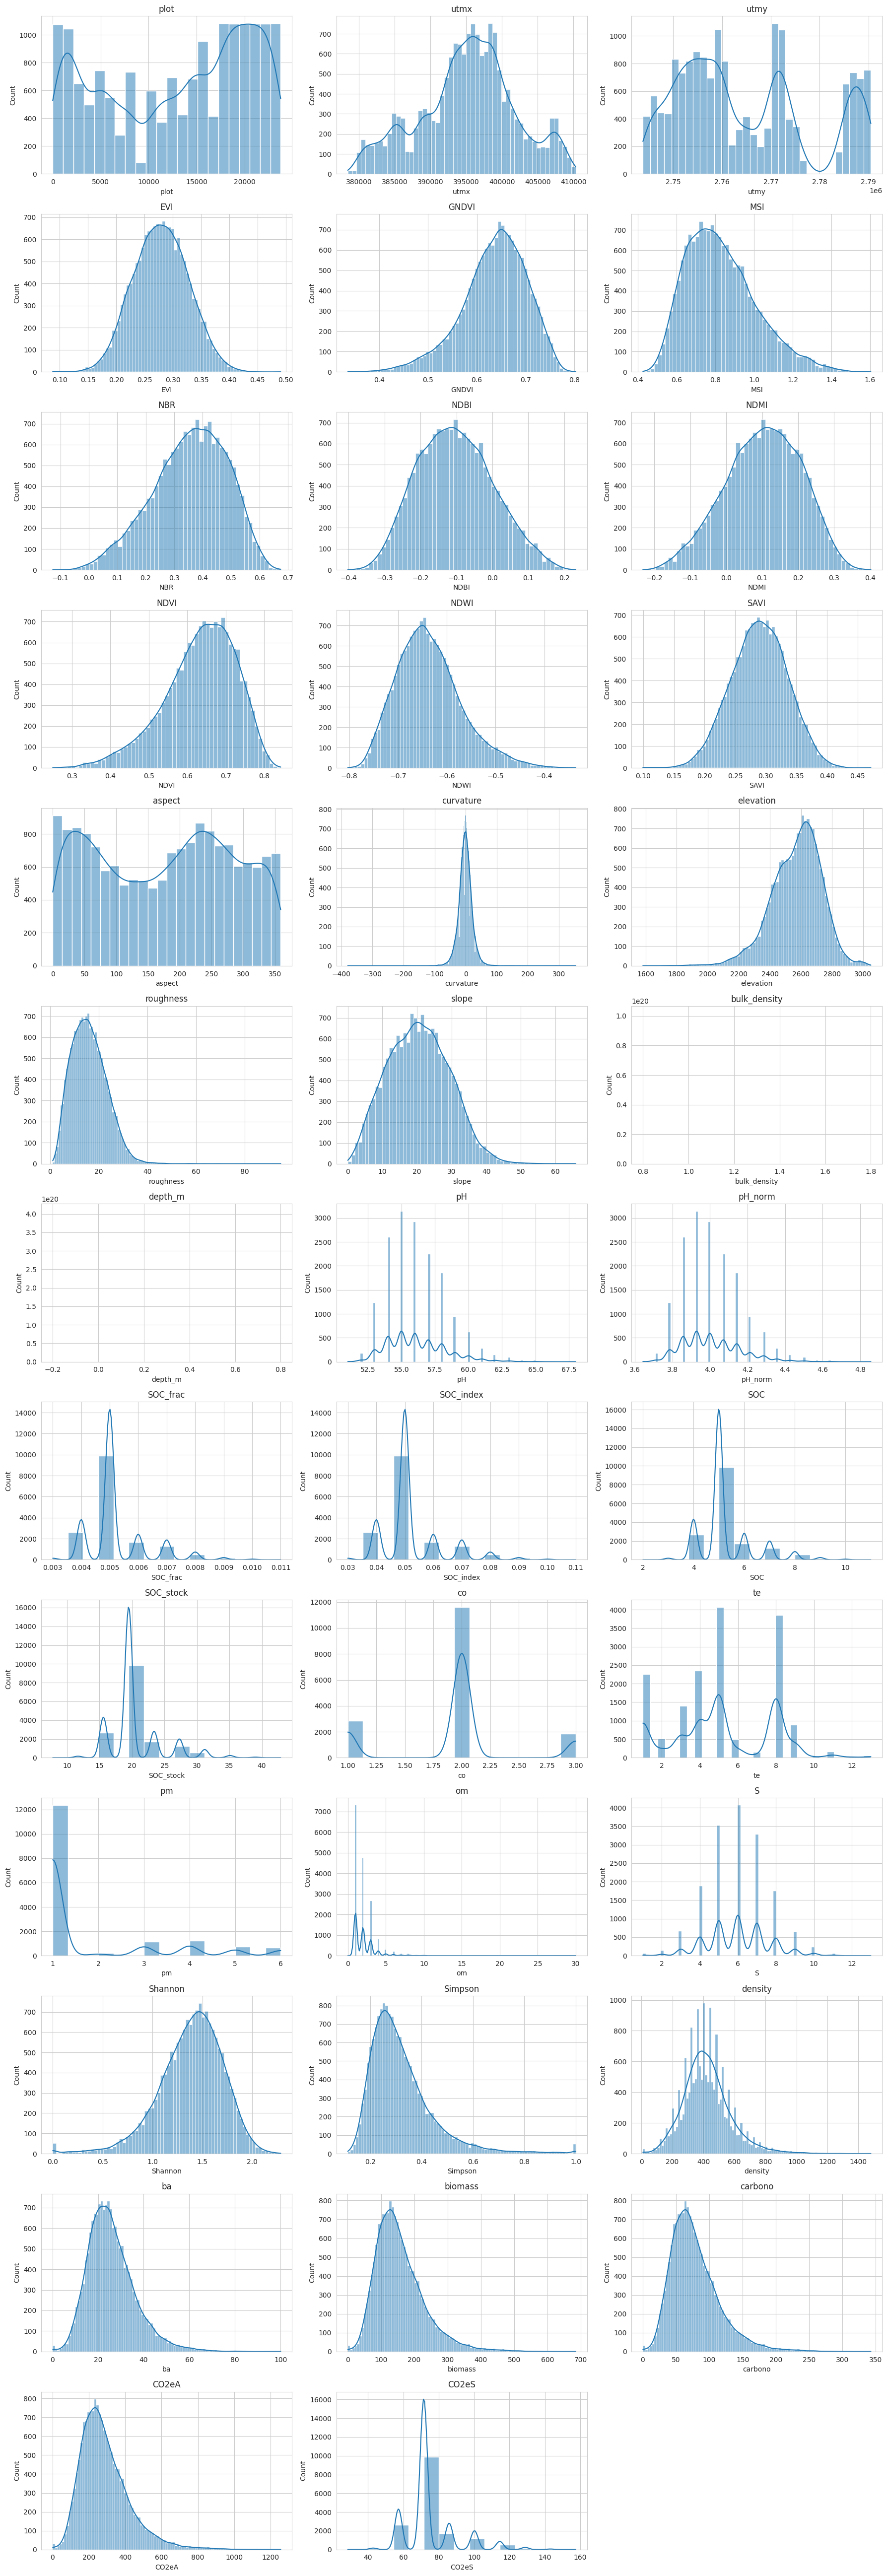

In [ ]:
#@title Histograma de variables numéricas
n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(n_rows,
                         n_cols,
                         figsize=(18, n_rows * 4))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.histplot(df[col],
                 kde=True,
                 ax=axes[i])

    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
#@title Cálculo de skewness
skewness = df[numerical_cols].skew()

print(skewness.sort_values(ascending=False))

om              4.848376
Simpson         1.875441
pm              1.710831
SOC_frac        1.447444
SOC_index       1.447444
SOC             1.444381
SOC_stock       1.444381
CO2eS           1.444381
biomass         1.266543
carbono         1.266543
CO2eA           1.266543
ba              0.961152
density         0.768461
pH              0.731627
pH_norm         0.731627
MSI             0.683985
NDWI            0.640936
roughness       0.638624
utmy            0.496244
slope           0.216881
NDBI            0.216638
curvature       0.199935
te              0.111447
S               0.110808
EVI             0.004231
bulk_density    0.000000
depth_m         0.000000
aspect         -0.036966
co             -0.058571
SAVI           -0.097357
utmx           -0.173071
NDMI           -0.216638
plot           -0.300922
NBR            -0.383340
elevation      -0.553319
GNDVI          -0.640936
NDVI           -0.647454
Shannon        -0.765254
dtype: float64


### Interpretación
Variables relacionadas con biomasa y CO2 equivalente podrían requerir transformaciones no lineales.

# 6. ¿Se identifican tendencias temporales? (En caso de que el conjunto incluya una dimensión de tiempo).

El conjunto de datos no incluye una dimensión temporal, por lo que no fue posible realizar análisis relacionados con tendencias en el tiempo, estacionalidad o cambios cronológicos en las variables. Debido a ello, el análisis exploratorio se enfocó principalmente en la distribución, calidad y relación entre las variables disponibles dentro del dataset

# 7. ¿Hay correlación entre las variables dependientes e independientes?


Estos bloques de código permiten analizar la relación existente entre las variables numéricas del conjunto de datos mediante una matriz de correlación. A través de un mapa de calor (heatmap), se visualiza la intensidad y dirección de las correlaciones, facilitando la identificación de relaciones positivas, negativas o redundancias entre variables. Posteriormente, se calcula específicamente la correlación de cada variable con la variable objetivo CO2eA, lo que ayuda a identificar los predictores con mayor influencia potencial para futuros análisis y modelos predictivos.

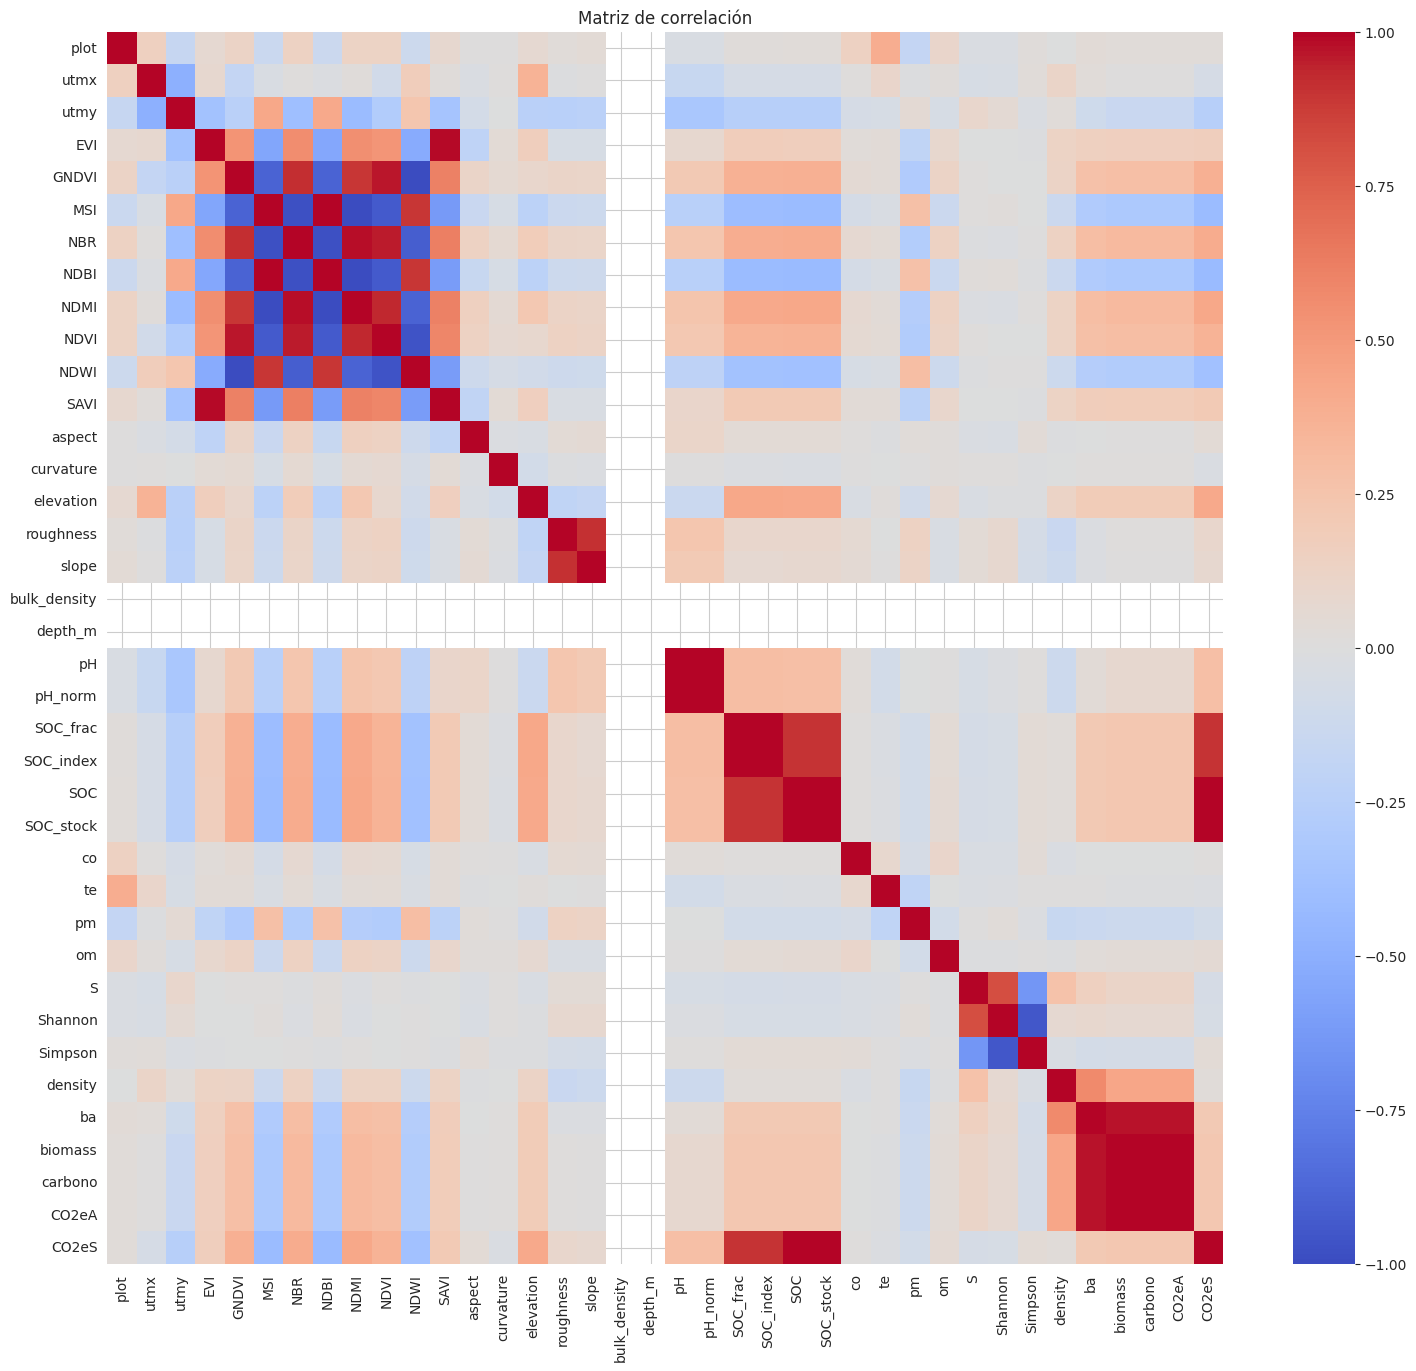

In [ ]:
#@title Matriz de correlación
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(18,16))

sns.heatmap(corr_matrix,
            cmap='coolwarm',
            center=0)

plt.title('Matriz de correlación')

plt.show()

In [ ]:
#@title Correlación con CO2eA
target_corr = corr_matrix['CO2eA'].sort_values(ascending=False)

print(target_corr)

CO2eA           1.000000
biomass         1.000000
carbono         1.000000
ba              0.971298
density         0.431763
NDMI            0.319126
NBR             0.315362
NDVI            0.291288
GNDVI           0.286995
SOC_stock       0.232988
SOC             0.232988
CO2eS           0.232988
SOC_index       0.230812
SOC_frac        0.230812
elevation       0.192648
SAVI            0.184449
EVI             0.162833
S               0.109877
pH_norm         0.071811
pH              0.071811
Shannon         0.065407
om              0.035545
plot            0.025092
curvature       0.014212
roughness       0.007861
utmx            0.005778
aspect          0.003136
slope           0.002512
co             -0.001238
te             -0.010225
Simpson        -0.069456
pm             -0.122390
utmy           -0.144822
NDWI           -0.286995
MSI            -0.316064
NDBI           -0.319126
bulk_density         NaN
depth_m              NaN
Name: CO2eA, dtype: float64


### Interpretación
Variables como biomass, carbono y ba muestran alta correlación positiva con CO2eA.

# 8. ¿Cómo se distribuyen los datos en función de diferentes categorías? (análisis bivariado)


Este bloque de código realiza un análisis bivariado entre variables seleccionadas y la variable objetivo CO2eA mediante gráficos de dispersión. Estas visualizaciones permiten explorar la relación y tendencia existente entre cada variable predictora y el dióxido de carbono equivalente, facilitando la identificación de patrones, asociaciones lineales o no lineales y posibles variables con mayor influencia en el comportamiento de la variable objetivo.

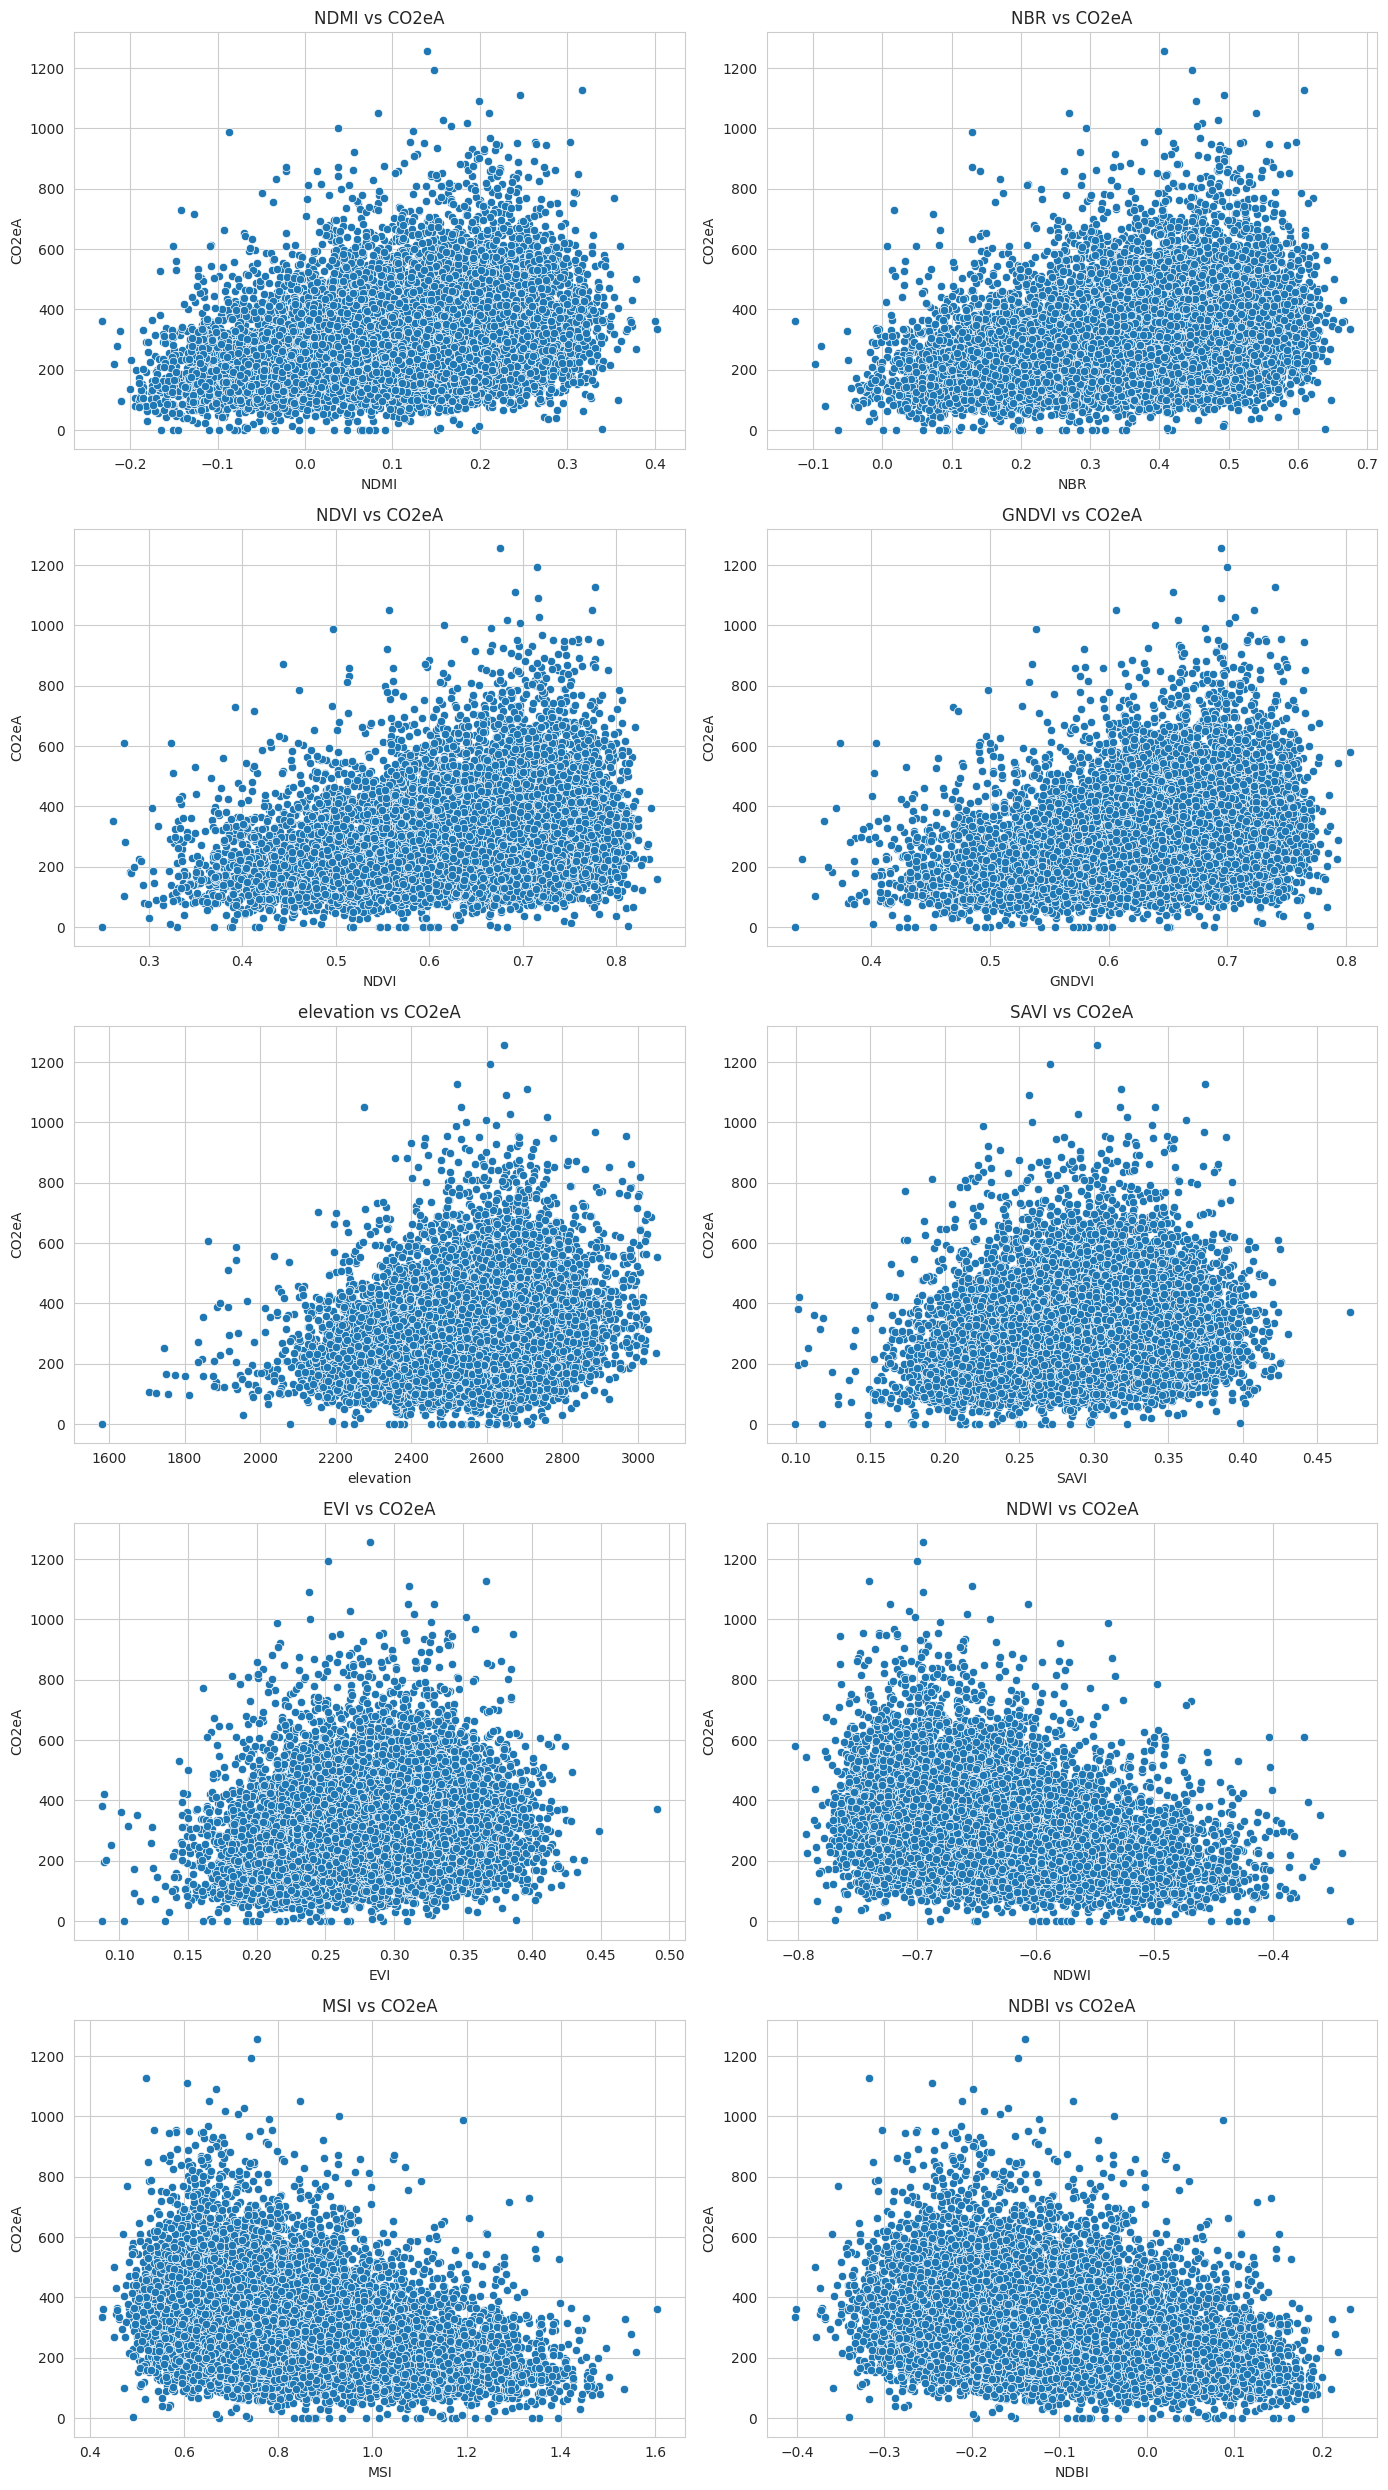

In [ ]:
#@title Análisis bivariado
important_vars = [
    'NDMI',
    'NBR',
    'NDVI',
    'GNDVI',
    'elevation',
    'SAVI',
    'EVI',
    'NDWI',
    'MSI',
    'NDBI'
]

n_cols = 2
n_rows = int(np.ceil(len(important_vars) / n_cols))

fig, axes = plt.subplots(n_rows,
                         n_cols,
                         figsize=(14, n_rows * 5))

axes = axes.flatten()

for i, col in enumerate(important_vars):

    sns.scatterplot(
        x=df[col],
        y=df['CO2eA'],
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs CO2eA')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

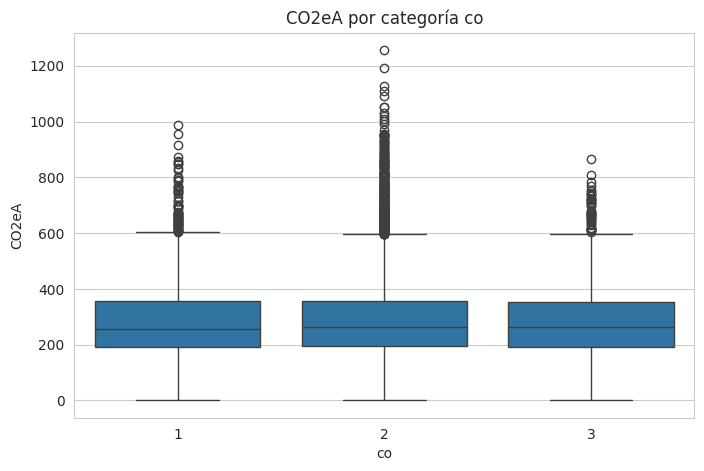

In [ ]:
#@title Análisis bivariado
plt.figure(figsize=(8,5))

sns.boxplot(x='co',
            y='CO2eA',
            data=df)

plt.title('CO2eA por categoría co')

plt.show()

### Interpretación
El análisis bivariado permite identificar relaciones entre variables ambientales y CO2eA.

# 9. ¿Se deberían normalizar las imágenes para visualizarlas mejor?


Este bloque de código realiza la normalización de las variables numéricas utilizando el método Min-Max, el cual transforma los valores a una escala entre 0 y 1. Este proceso permite homogenizar la magnitud de las variables, evitando que aquellas con rangos mayores tengan una influencia desproporcionada en los análisis y modelos de aprendizaje automático.

In [ ]:
#@title Normalización
scaler = MinMaxScaler()

normalized_data = scaler.fit_transform(df[numerical_cols])

normalized_df = pd.DataFrame(normalized_data,
                             columns=numerical_cols)

normalized_df.head()

,plot,utmx,utmy,EVI,GNDVI,MSI,NBR,NDBI,NDMI,NDVI,NDWI,SAVI,aspect,curvature,elevation,roughness,slope,bulk_density,depth_m,pH,pH_norm,SOC_frac,SOC_index,SOC,SOC_stock,co,te,pm,om,S,Shannon,Simpson,density,ba,biomass,carbono,CO2eA,CO2eS
0,0.000000,0.329098,0.995270,0.370989,0.481931,0.543719,0.370892,0.685100,0.314900,0.440970,0.518069,0.413236,0.188470,0.547067,0.739101,0.061679,0.182424,0.0,0.0,0.352941,0.352941,0.25,0.25,0.333333,0.333333,0.0,0.083333,0.0,0.033333,0.416667,0.657602,0.154948,0.367347,0.421863,0.365253,0.365253,0.365253,0.333333
1,0.000042,0.330667,0.995955,0.287614,0.410835,0.641879,0.281247,0.765938,0.234062,0.363603,0.589165,0.318351,0.164116,0.518417,0.735695,0.041051,0.054465,0.0,0.0,0.235294,0.235294,0.25,0.25,0.333333,0.333333,0.0,0.000000,0.0,0.033333,0.583333,0.845597,0.047594,0.312925,0.239609,0.201616,0.201616,0.201616,0.333333
2,0.000084,0.328346,0.998523,0.420546,0.665261,0.363706,0.552168,0.510667,0.489333,0.684536,0.334739,0.470825,0.115587,0.525239,0.730926,0.117086,0.272688,0.0,0.0,0.352941,0.352941,0.25,0.25,0.333333,0.333333,0.5,0.083333,0.0,0.100000,0.500000,0.670516,0.171376,0.238095,0.329400,0.323465,0.323465,0.323465,0.333333
3,0.000126,0.335655,0.996255,0.400964,0.615500,0.399142,0.496107,0.548088,0.451912,0.568244,0.384500,0.448796,0.887395,0.508868,0.743188,0.052205,0.093631,0.0,0.0,0.235294,0.235294,0.25,0.25,0.333333,0.333333,0.5,0.000000,0.0,0.033333,0.416667,0.615849,0.188851,0.374150,0.290012,0.254405,0.254405,0.254405,0.333333
4,0.000168,0.334682,0.998095,0.403266,0.559014,0.374530,0.480249,0.522275,0.477725,0.507446,0.440986,0.448001,0.029083,0.529332,0.732970,0.062928,0.085638,0.0,0.0,0.235294,0.235294,0.25,0.25,0.333333,0.333333,0.5,0.083333,0.0,0.033333,0.333333,0.520273,0.274795,0.272109,0.336392,0.341020,0.341020,0.341020,0.333333


### Interpretación
La normalización reduce diferencias de escala y mejora la visualización.

# 10. ¿Hay desequilibrio en las clases de la variable objetivo?


Este bloque de código permite analizar la distribución de la variable objetivo CO2eA mediante un histograma y una curva de densidad. Esta visualización facilita la identificación de posibles desequilibrios, concentraciones de datos o distribuciones sesgadas, aspectos importantes para evaluar la representatividad de los datos antes del modelado predictivo.

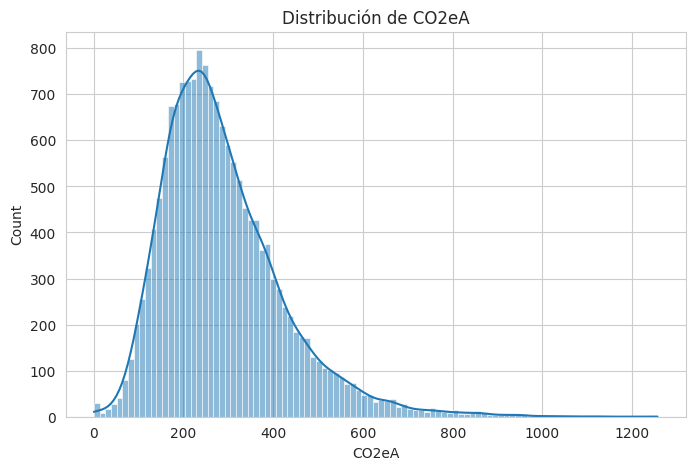

In [ ]:
#@title Análisis de desequilibrio de clases
plt.figure(figsize=(8,5))

sns.histplot(df['CO2eA'],
             kde=True)

plt.title('Distribución de CO2eA')

plt.show()

### Interpretación
CO₂eA corresponde a un problema de regresión, por lo que el análisis tradicional de desbalance de clases no aplica directamente.

La distribución de la variable CO₂eA presenta un comportamiento asimétrico positivo (sesgo a la derecha), donde la mayor concentración de observaciones se encuentra aproximadamente entre 150 y 400 unidades de CO₂ equivalente por hectárea. Asimismo, se observa una cola larga hacia valores altos, indicando la presencia de algunos registros con concentraciones considerablemente mayores al promedio. Este comportamiento sugiere que la variable no sigue una distribución normal y que existen valores extremos que podrían influir en futuros análisis y modelos predictivos. Sin embargo, la mayoría de los datos se concentra en rangos intermedios, lo cual proporciona una base adecuada para el análisis estadístico y el entrenamiento de modelos de aprendizaje automático.

# Conclusiones



El Análisis Exploratorio de Datos (EDA) permitió comprender de manera integral la estructura, calidad y comportamiento del conjunto de datos utilizado en el proyecto. A través de las diferentes etapas desarrolladas en el notebook, fue posible identificar la composición general del dataset, los tipos de variables y las principales estadísticas descriptivas, proporcionando una base sólida para las etapas posteriores de análisis y modelado.

El análisis de valores faltantes permitió evaluar la calidad de la información y detectar posibles patrones de ausencia de datos, mientras que la visualización mediante mapas de calor facilitó la interpretación de dichas inconsistencias. Asimismo, el análisis de valores atípicos mediante diagramas de caja y el método del Rango Intercuartílico (IQR) permitió identificar observaciones extremas que podrían influir en el desempeño de futuros modelos predictivos.

Por otra parte, el análisis de cardinalidad y distribución de variables categóricas ayudó a comprender la diversidad y frecuencia de las categorías presentes en el conjunto de datos, permitiendo detectar posibles desbalances. De igual manera, el estudio de las distribuciones numéricas y el cálculo de la asimetría (skewness) evidenciaron que algunas variables presentan comportamientos sesgados, lo cual sugiere la posible necesidad de aplicar transformaciones o procesos de escalamiento.

El análisis de correlación y los gráficos bivariados permitieron identificar relaciones importantes entre las variables predictoras y la variable objetivo CO₂eA, facilitando la detección de variables potencialmente relevantes para futuros modelos de aprendizaje automático. Además, la normalización mediante Min-Max Scaling permitió homogenizar las escalas de las variables numéricas, preparando adecuadamente los datos para algoritmos sensibles a diferencias de magnitud.

Finalmente, el análisis de la distribución de la variable objetivo permitió evaluar posibles desequilibrios en los datos y comprender mejor su comportamiento general. En conjunto, el EDA desarrollado constituye una etapa fundamental para garantizar la calidad, consistencia y adecuada preparación del dataset antes de aplicar técnicas de modelado predictivo y análisis avanzado de datos.